# Usage of torchMWRT

`torchMWRT` is a PyTorch translation of the radiative transfer calculation core of `PyRTlib`. It is designed to be faster than the original `PyRTlib` while still producing the same results.

This is achieved by vectorizing all calculations over frequencies, angles, height levels, and any leading dimensions such as time or location. The calculations can be further accelerated using GPU support provided by PyTorch, although this is not necessary in most cases.

The following code demonstrates how to use torchMWRT to calculate brightness temperatures.

In [1]:
%config InlineBackend.figure_format = 'svg'

import numpy as np
import xarray as xr
import time
import matplotlib.pyplot as plt

from torchMWRT import AtmProfile, RTModel

FREQS = np.array([22.24,23.04,23.84,25.44,26.24,27.84,31.40,51.26,52.28,53.86,54.94,56.66,57.30,58.00])
ANGLES = np.array([90.0], dtype=float)

DATA_DIR = '../../../../data'

Let's start by loading the radiosonde data set created in the [Create a Retrieval](#create_retrieval) Section.

In [2]:
ds = xr.load_dataset(f"{DATA_DIR}/sites/munich_G5/radiosonde/radiosonde_data_03715.nc")[['T', 'p', 'rh', 'lwc']]
ds

<xarray.Dataset> Size: 147MB
Dimensions:  (synop: 22040, height: 208)
Coordinates:
  * synop    (synop) datetime64[ns] 176kB 1990-01-01 ... 2026-02-21
  * height   (height) int64 2kB 0 10 25 50 75 ... 28000 28500 29000 29500 30000
Data variables:
    T        (synop, height) float64 37MB 267.1 267.1 267.1 ... 219.6 220.5
    p        (synop, height) float64 37MB 963.2 962.0 960.2 ... 10.73 9.947
    rh       (synop, height) float64 37MB 96.6 95.27 93.27 ... 2.035 2.066 2.088
    lwc      (synop, height) float64 37MB 0.0 0.007414 0.01853 ... 0.0 0.0 0.0
Attributes:
    station_id:      03715
    station_name:    Oberschleißheim (Lustheim)
    station_height:  484
    station_lat:     48.2446
    station_lon:     11.5525

## Run torchMWRT for a Single Profile

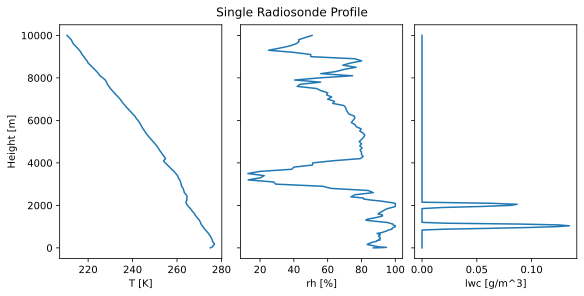

<xarray.Dataset> Size: 8kB
Dimensions:  (height: 208)
Coordinates:
  * height   (height) int64 2kB 0 10 25 50 75 ... 28000 28500 29000 29500 30000
    synop    datetime64[ns] 8B 2026-02-21
Data variables:
    T        (height) float64 2kB 274.9 275.3 275.6 275.9 ... 218.5 219.6 220.5
    p        (height) float64 2kB 966.6 965.4 963.6 960.7 ... 11.59 10.73 9.947
    rh       (height) float64 2kB 87.0 92.0 94.73 90.0 ... 2.035 2.066 2.088
    lwc      (height) float64 2kB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0 0.0
Attributes:
    station_id:      03715
    station_name:    Oberschleißheim (Lustheim)
    station_height:  484
    station_lat:     48.2446
    station_lon:     11.5525

In [3]:
ds_date = ds.isel(synop= -1)

fig, axs = plt.subplots(ncols=3, sharey=True, figsize=(8, 4), constrained_layout=True)

ds_date['T'].sel(height=slice(0,10000)).plot(y='height', ax=axs[0])
ds_date['rh'].sel(height=slice(0,10000)).plot(y='height', ax=axs[1])
ds_date['lwc'].sel(height=slice(0,10000)).plot(y='height', ax=axs[2])

for i, ax in enumerate(axs):
    ax.set_ylabel("" if i > 0 else "Height [m]")
    ax.set_title('')
fig.suptitle('Single Radiosonde Profile')

plt.show()

ds_date

The first step is to create an instance of the `RTModel` class, which owns the radiative transfer code. In the initialization, all the settings are defined, such as the frequencies and angles for which the calculations should be performed, the absorption model to use, whether to simulate measurements from the surface or from a satellite.

In [4]:
rtmodel = RTModel(freqs=FREQS, angles=ANGLES, absmdl="R17")

The next step is to create an `AtmProfile` object, which holds the atmospheric profile data. The `AtmProfile` class is designed to be flexible and can handle different input types, like numpy arrays, xarray DataArrays, or PyTorch tensors. The only requirement is that they all share the same height dimension / coordinate. To run a clear sky simulation just omit the lwc and the iwc variables.

In [5]:
atm_profile = AtmProfile(
    temperature=ds_date["T"],
    height=ds_date["height"],
    pressure=ds_date["p"],
    rh=ds_date["rh"] / 100.0,
    lwc=ds_date["lwc"],
)

Finally, the `execute` method of the `RTModel` instance is called to perform the radiative transfer calculations. The results can be returned as an xarray Dataset.

In [6]:
result_ds = rtmodel.execute(atm_profile, return_ds=True)
result_ds["tbtotal"]

<xarray.DataArray 'tbtotal' (frq: 14, ang: 1)> Size: 112B
array([[ 28.81278599],
       [ 27.64180941],
       [ 24.29956104],
       [ 19.07339972],
       [ 17.68918404],
       [ 16.42028042],
       [ 16.89313523],
       [104.27898408],
       [142.87996218],
       [239.04810181],
       [269.35150176],
       [274.62096968],
       [275.0700758 ],
       [275.33194293]])
Coordinates:
  * frq      (frq) float64 112B 22.24 23.04 23.84 25.44 ... 56.66 57.3 58.0
  * ang      (ang) float64 8B 90.0

## Run torchMWRT for Multiple Profiles

The `RTModel` and `AtmProfile` classes are designed to be run on multiple profiles in parallel / vectorized. To do this, simply add leading dimensions to the profile variables, for example by stacking multiple profiles along a new "time" dimension. The `execute` method will automatically perform the calculations for all profiles in parallel and return the results with the same leading dimensions. 

In this example, the code is executed on 1000 profiles. Note that the `RTModel` instance can be reused for different profiles, so the initialization overhead is incurred only once.

In [7]:
ds_1000 = ds.isel(synop=slice(-1001, -1))
ds_1000

<xarray.Dataset> Size: 7MB
Dimensions:  (synop: 1000, height: 208)
Coordinates:
  * synop    (synop) datetime64[ns] 8kB 2024-10-20T12:00:00 ... 2026-02-20T18...
  * height   (height) int64 2kB 0 10 25 50 75 ... 28000 28500 29000 29500 30000
Data variables:
    T        (synop, height) float64 2MB 288.3 287.3 286.2 ... 203.6 206.2 208.4
    p        (synop, height) float64 2MB 967.0 965.8 964.1 ... 10.14 9.334 8.595
    rh       (synop, height) float64 2MB 80.14 85.86 92.2 92.58 ... 2.0 2.0 2.0
    lwc      (synop, height) float64 2MB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
Attributes:
    station_id:      03715
    station_name:    Oberschleißheim (Lustheim)
    station_height:  484
    station_lat:     48.2446
    station_lon:     11.5525

In [8]:
start = time.perf_counter()

atm_profile = AtmProfile(
    temperature=ds_1000["T"],
    height=ds_1000["height"],
    pressure=ds_1000["p"],
    rh=ds_1000["rh"] / 100.0,
    lwc=ds_1000["lwc"],
)
result_ds = rtmodel.execute(atm_profile, return_ds=True)

end = time.perf_counter()

print(f"Elapsed time: {end - start:.3f} seconds")

result_ds["tbtotal"]

Elapsed time: 1.658 seconds


<xarray.DataArray 'tbtotal' (synop: 1000, frq: 14, ang: 1)> Size: 112kB
array([[[ 52.05499361],
        [ 49.30037352],
        [ 41.6287104 ],
        ...,
        [284.93592111],
        [284.95471599],
        [284.93810103]],

       [[ 50.32336476],
        [ 47.43428159],
        [ 39.85995939],
        ...,
        [285.606027  ],
        [285.5579183 ],
        [285.45227132]],

       [[ 46.84885243],
        [ 44.088421  ],
        [ 37.03379201],
        ...,
...
        ...,
        [270.06910101],
        [270.4867661 ],
        [270.76314251]],

       [[ 24.26275865],
        [ 23.2799833 ],
        [ 20.28705312],
        ...,
        [270.77442228],
        [271.1585723 ],
        [271.41547469]],

       [[ 28.77178129],
        [ 28.1277405 ],
        [ 25.38258218],
        ...,
        [272.39975957],
        [272.7973637 ],
        [273.05728277]]], shape=(1000, 14, 1))
Coordinates:
  * synop    (synop) datetime64[ns] 8kB 2024-10-20T12:00:00 ... 2026-02-20T18...
  * frq      (frq) float64 112B 22.24 23.04 23.84 25.44 ... 56.66 57.3 58.0
  * ang      (ang) float64 8B 90.0